<a href="https://colab.research.google.com/github/tang1114/Durian-Disease-Detection/blob/dev/Model_Durian_Leaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### [1] การเตรียม Data และ ImageDataGenerator

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# --- ตั้งค่าตำแหน่งของ Dataset ---
dataset_path = '/content/drive/MyDrive/Colab Notebooks/Durian Leaf Disease/dataset'
train_path = dataset_path + '/train'
val_path = dataset_path + '/val'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # สำคัญมาก: ต้องเป็น False เพื่อให้ทำ Matrix ได้ถูกต้อง
)

Found 1814 images belonging to 6 classes.
Found 387 images belonging to 6 classes.


### [2] การสร้าง Base Model และ Training Phase 1

In [ ]:
# สร้าง Base Model จาก MobileNetV2 (Pre-trained on ImageNet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # แช่แข็งน้ำหนักไว้ก่อนในรอบแรก

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_all_entropy' if train_generator.num_classes == 2 else 'categorical_crossentropy',
              metrics=['accuracy'])

# Phase 1: Training top layers
print("Starting Phase 1: Training top layers...")
history = model.fit(train_generator, epochs=10, validation_data=validation_generator)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting Phase 1: Training top layers...
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 729s 12s/step - accuracy: 0.4476 - loss: 1.4872 - val_accuracy: 0.6718 - val_loss: 0.9147
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 588ms/step - accuracy: 0.7227 - loss: 0.8199 - val_accuracy: 0.7261 - val_loss: 0.7386
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 36s 618ms/step - accuracy: 0.7740 - loss: 0.6643 - val_accuracy: 0.7700 - val_loss: 0.6280
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 597ms/step - accuracy: 0.7822 - loss: 0.6089 - val_accuracy: 0.8062 - val_loss: 0.5879
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 615ms/step - accuracy: 0.8082 - loss: 0.5476 - val_accuracy: 0.8165 - val_loss: 0.5483
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 609ms/step - accuracy: 0.8164 - loss: 0.5247 - val_accuracy: 0.8088 - val_loss: 0.4933
Epoch 7/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 37s 642ms/step - accuracy: 0.8335 - loss: 0.4799 - val_accuracy: 0.8191 - val_loss: 0.4919
Epoch 8/

### [3] การคำนวณ Class Weights เพื่อปรับสมดุล

In [ ]:
import numpy as np
from sklearn.utils import class_weight

# 1. คำนวณ Class Weights เพื่อเน้นคลาสที่มีปัญหา
class_series = train_generator.classes
weights = class_weight.compute_class_weight('balanced',
                                            classes=np.unique(class_series),
                                            y=class_series)
class_weights = dict(enumerate(weights))

# เพิ่มน้ำหนักเป็นพิเศษให้ Leaf_Blight (ID: 1) และ Leaf_Rhizoctonia (ID: 5)
# (ตัวเลข 1.5 หรือ 2.0 คือการเน้นความสำคัญเพิ่มขึ้น)
class_weights[1] = class_weights[1] * 1.5
class_weights[5] = class_weights[5] * 2.0

print("Adjusted Class Weights:", class_weights)

Adjusted Class Weights: {0: np.float64(0.936016511867905), 1: np.float64(1.4724025974025974), 2: np.float64(1.0797619047619047), 3: np.float64(0.8944773175542406), 4: np.float64(1.0534262485481998), 5: np.float64(2.175059952038369)}


### [4] การเทรนขั้นสูง Intensive Fine-tuning

In [ ]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_mean(alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1 + tf.keras.backend.epsilon())) - tf.reduce_mean((1 - alpha) * tf.pow(pt_0, gamma) * tf.math.log(1. - pt_0 + tf.keras.backend.epsilon()))
    return focal_loss_fixed

# ใช้ Learning Rate ที่นิ่งและต่ำมาก
initial_learning_rate = 1e-6

model.compile(
    optimizer=optimizers.Adam(learning_rate=initial_learning_rate),
    loss='categorical_crossentropy', # หรือลองเปลี่ยนเป็น focal_loss() ถ้ามี library รองรับ แต่ใช้ Crossentropy + LR ต่ำก็ช่วยได้มาก
    metrics=['accuracy']
)

# ลด Learning Rate เมื่อ Accuracy ไม่พัฒนา (Plateau)
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

print("Starting Intensive Fine-tuning for Leaf_Blight...")
history_final = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    class_weight=class_weights, # ยังคงใช้น้ำหนักที่คำนวณไว้
    callbacks=[lr_reducer]
)

model.save('best_mobilenetv2_ultra.keras')
print("Ultra Model Saved!")

Starting Intensive Fine-tuning for Leaf_Blight...
Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 75s 934ms/step - accuracy: 0.9890 - loss: 0.0379 - val_accuracy: 0.9406 - val_loss: 0.2576 - learning_rate: 1.0000e-06
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 594ms/step - accuracy: 0.9917 - loss: 0.0403 - val_accuracy: 0.9432 - val_loss: 0.2529 - learning_rate: 1.0000e-06
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 589ms/step - accuracy: 0.9934 - loss: 0.0294 - val_accuracy: 0.9406 - val_loss: 0.2497 - learning_rate: 1.0000e-06
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 35s 616ms/step - accuracy: 0.9912 - loss: 0.0368 - val_accuracy: 0.9406 - val_loss: 0.2479 - learning_rate: 1.0000e-06
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 597ms/step - accuracy: 0.9873 - loss: 0.0387 - val_accuracy: 0.9406 - val_loss: 0.2473 - learning_rate: 1.0000e-06
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 34s 601ms/step - accuracy: 0.9912 - loss: 0.0326 - val_accuracy: 0.9406 - val_loss: 0.2468 - learning_rate: 1.0000e-06
Epoch 7/

### [5] การประเมินผลด้วย Confusion Matrix

Generating predictions...
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 655ms/step


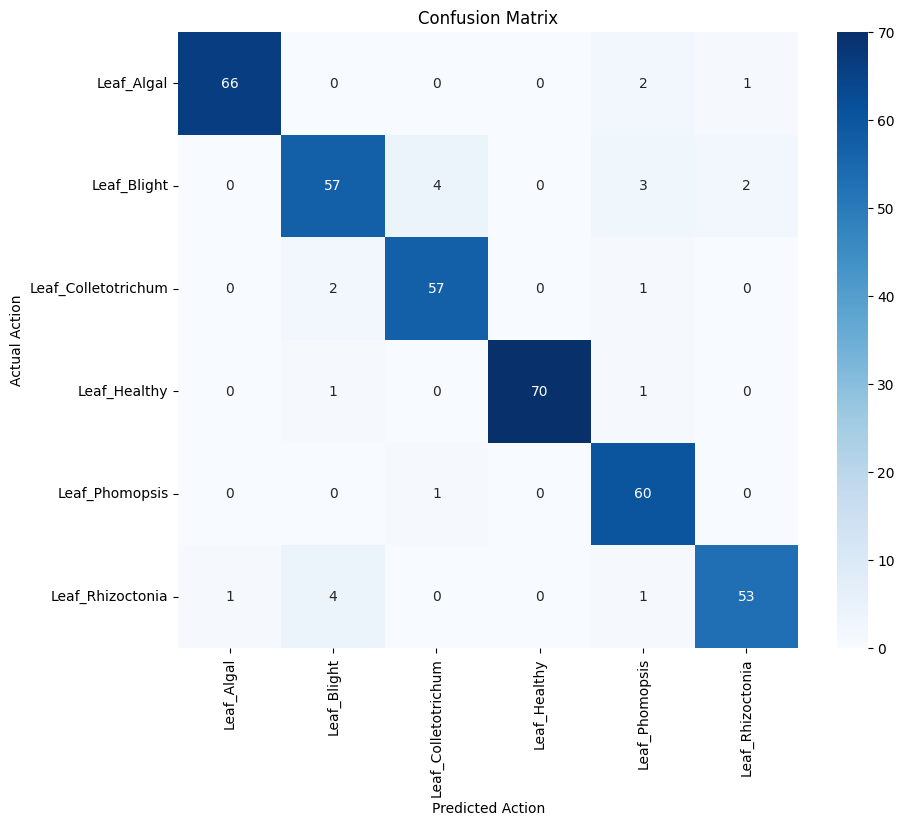


Classification Report
                     precision    recall  f1-score   support

         Leaf_Algal       0.99      0.96      0.97        69
        Leaf_Blight       0.89      0.86      0.88        66
Leaf_Colletotrichum       0.92      0.95      0.93        60
       Leaf_Healthy       1.00      0.97      0.99        72
     Leaf_Phomopsis       0.88      0.98      0.93        61
   Leaf_Rhizoctonia       0.95      0.90      0.92        59

           accuracy                           0.94       387
          macro avg       0.94      0.94      0.94       387
       weighted avg       0.94      0.94      0.94       387



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Predict values from validation set
print("Generating predictions...")
validation_generator.reset()
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual Action')
plt.xlabel('Predicted Action')
plt.show()

# 4. Print Classification Report
print('\nClassification Report')
print(classification_report(y_true, y_pred, target_names=class_labels))